# Set the Working Directory 
Always set the current working directory to the root of the repo so you can import the helper functions 

In [1]:
from pathlib import Path
import os 

cwd = Path.cwd()

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

# Libraries 

In [2]:
from utils.checkpoints import load_checkpoint
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from utils.checkpoints import load_ckpt_any, latest_checkpoint_path, train_dir, make_train_id
from utils.runs import load_by_params


In [3]:
df_idx = pd.read_parquet(cwd/"results"/"index"/"training.parquet")
df_dgp_idx = pd.read_parquet(cwd/"data/index/runs_monotone_included.parquet")
aux = {"a":[], "p":[]}
for i, row in df_idx.iterrows():
    run_id = row["data_run_id"]
    dgp_row = df_dgp_idx[df_dgp_idx["run_id"]==run_id]
    config = json.loads(json.loads(dgp_row["config"].values[0]))
    if len(dgp_row) == 1:
        aux["a"].append(config["a"])
        aux["p"].append(config["p"])
    else:
        aux["a"].append(np.nan)
        aux["p"].append(np.nan)

aux_df = pd.DataFrame(aux, index=df_idx.index)
df_idx = pd.concat([df_idx, aux_df], axis=1)

df_idx = df_idx.query("model == 'seqgplvm' and cfg_N ==250 and cfg_T == 40 and a == 2 and p == 2")
df_idx.head(50)


,model,train_id,data_run_id,path,created_at,git_commit,cfg_N,cfg_T,cfg_C,cfg_latent_dim,...,cfg_treatment_lag,cfg_treatment_model,cfg_init_z,cfg_learn_inducing_locations,cfg_use_titsias,cfg_lr,metrics_json,final_loss,a,p
16,seqgplvm,086c3fee44,cb059083,results/models/seqgplvm/086c3fee44,2025-11-26T23:01:10Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.242961883544922,""epochs_compl...",23.242962,2,2
27,seqgplvm,ee7666ff33,3ae15795,results/models/seqgplvm/ee7666ff33,2025-11-26T23:26:01Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.348552703857422,""epochs_compl...",23.348553,2,2
32,seqgplvm,95cf1ae82c,bc46dcb3,results/models/seqgplvm/95cf1ae82c,2025-11-26T23:36:45Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.731605529785156,""epochs_compl...",23.731606,2,2
57,seqgplvm,fc5071359f,9a9edac0,results/models/seqgplvm/fc5071359f,2025-11-27T00:06:33Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.431821823120117,""epochs_compl...",23.431822,2,2
93,seqgplvm,1d766aeed0,fd502106,results/models/seqgplvm/1d766aeed0,2025-11-27T01:11:34Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.29930305480957,""epochs_comple...",23.299303,2,2
139,seqgplvm,40c44d0c61,502dabe2,results/models/seqgplvm/40c44d0c61,2025-11-27T02:18:48Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.84748649597168,""epochs_comple...",23.847486,2,2
141,seqgplvm,602d5a0cf8,37cb0252,results/models/seqgplvm/602d5a0cf8,2025-11-27T02:19:56Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.667926788330078,""epochs_compl...",23.667927,2,2
184,seqgplvm,18056a2269,1b25d891,results/models/seqgplvm/18056a2269,2025-11-27T03:15:47Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.002805709838867,""epochs_compl...",23.002806,2,2
220,seqgplvm,07d59c350c,abb20e0e,results/models/seqgplvm/07d59c350c,2025-11-27T04:14:38Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.672040939331055,""epochs_compl...",23.672041,2,2
248,seqgplvm,e401b91ac2,4c01e626,results/models/seqgplvm/e401b91ac2,2025-11-27T05:00:52Z,None,250.0,40.0,3.0,1.0,...,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,False,False,0.01,"{""final_loss"":23.629322052001953,""epochs_compl...",23.629322,2,2


In [120]:
df_idx.train_id.values

array(['086c3fee44', 'ee7666ff33', '95cf1ae82c', 'fc5071359f',
       '1d766aeed0', '40c44d0c61', '602d5a0cf8', '18056a2269',
       '07d59c350c', 'e401b91ac2', '683b961073', '4961052216',
       '4b32d532ee', 'f946788ae5', '1f630f8055'], dtype=object)

In [4]:
from dgps import get_simulator
from utils.pathing import as_path

model_name = "seqgplvm"
device = "cuda"
tid = 9
#train_id = df_idx.train_id.unique()[tid]

train_id = "ee7666ff33"

'''
train_out = cwd / train_dir(Path(os.environ.get("FINAL_ROOT", "./results")).expanduser(), model_name, train_id)
data_path = json.loads((train_out / "data_ref.json").read_text(encoding="utf-8"))["data_file"]
df = pd.read_parquet(cwd/Path(data_path)/"data.parquet")
df_manifest = json.loads((cwd/Path(data_path)/"manifest.json").read_text(encoding="utf-8"))
splits  = json.loads((cwd/Path(df_manifest["split_file"])).read_text(encoding="utf-8"))
train_split = splits["train_ids"]
val_split   = splits["val_ids"] + splits["test_ids"]
''' 
train_out = cwd / "results" / "models" / f"{model_name}" / train_id
ckpt_path = latest_checkpoint_path(train_out)
payload = load_ckpt_any(ckpt_path, map_location=device)
manifest = json.loads((train_out / "data_ref.json").read_text(encoding="utf-8"))
config = json.loads((train_out / "config.json").read_text(encoding="utf-8"))

data_config = json.loads(json.loads(df_dgp_idx[df_dgp_idx.run_id == manifest["data_run_id"]]["config"].iloc[0]))
mani = json.loads(df_dgp_idx[df_dgp_idx.run_id == manifest["data_run_id"]]["manifest"].iloc[0])

simulate = get_simulator(data_config["dgp"])
df = simulate(data_config)

with open(as_path(Path(".") / mani["split_file"]), "r", encoding="utf-8") as f:
    splits = json.load(f)

train_split = splits["train_ids"] 
val_split   = splits["val_ids"] + splits["test_ids"]


extra = payload.get("extra")
loss_list     = extra.get("loss_list")
param_hist    = extra.get("param_hist")
actual_params = extra.get("actual_params")

step = config["logging"]["param_logging_freq"]


id_col = "patient_id"  

uniq_ids = df[id_col].unique()
id2row = {pid: i for i, pid in enumerate(uniq_ids)}
if config["drop_monotone"]:
    from utils.preprocessings import split_monotone_ids

    treatment_col = "D"
    monotone_info = split_monotone_ids(
            df, id_col=id_col, treatment_col=treatment_col
        )
    
    variable_ids = set(monotone_info["variable"])
    
    train_split = [pid for pid in train_split if pid in variable_ids]
train_ids_kept = [pid for pid in train_split if pid in id2row]     # X_train's row order
row_of = {pid: i for i, pid in enumerate(train_ids_kept)}         # pid -> row index in X_train

df_train = df[df[id_col].isin(train_ids_kept)].copy()
df_train["train_row"] = df_train[id_col].map(row_of)
df_train = df_train.sort_values(["patient_id", "t"])          # now blocks match X_train rows

# Loss 

In [5]:
import matplotlib.pyplot as plt

if len(loss_list) == 1:
    print("Only one loss logged, skipping plot \n loss:", loss_list[0])
else:

    last_n_step = 10
    fig,ax = plt.subplots(1,2,figsize = (10,3))
    ax[0].plot(np.arange(len(loss_list)) * step , loss_list)
    ax[1].plot(range((len(loss_list)- last_n_step) * step , len(loss_list) * step , step) ,loss_list[-last_n_step:])
    ax[0].set_title("Loss over training")
    ax[0].set_xlabel("Training step")
    ax[0].set_ylabel("Loss")
    plt.show()

Only one loss logged, skipping plot 
 loss: 23.348552703857422


# Params

In [7]:
specials = {"q_mu": "Z.q_mu", "q_log_sigma": "Z.q_log_sigma"}
specials_val = {"q_mu": "Z_val.q_mu", "q_log_sigma": "Z_val.q_log_sigma"}

if model_name.endswith("_val"):
    specials = specials_val
params = [specials.get(s, s) for s in dict.fromkeys(k.rsplit('.', 1)[-1] for k in param_hist)]

params

['Z.q_mu', 'Z.q_log_sigma', 'raw_constant', 'raw_variance']

In [154]:
from utils.inspectors import plot_param_history

key = 'Z.q_mu'
fig = plot_param_history(param_hist = param_hist, key= key, ls_num=3, x_start= 0, x_step=config["logging"]["param_logging_freq"])
fig

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

## Linear Weights 

In [155]:
weights = []
for t in range(config["T"]): 
    weights.append(param_hist[f"gps.{t}.mean_module.weights"][-1])
weights =np.array(weights).squeeze()

KeyError: 'gps.0.mean_module.weights'

In [156]:
plt.plot(weights[:,3], "--.")

TypeError: list indices must be integers or slices, not tuple

## Correlation Between the Estimated Latent and The Real Variable 

# Propensity Score 

In [159]:
from trainers.seqgplvm_propensity import propensity_seqgplvm 

propensity_seqgplvm(train_id= train_id, sample_count=100, load_data=False, save_propensity=True, dgp_index_path= cwd/"data/index/runs_monotone_included.parquet", drop_monotone=config["drop_monotone"])

Saved log–GPS tensor to: results\propensity\seqgplvm\ee7666ff33\loggps_ee7666ff33.pt  shape=(250, 40, 100)


In [16]:
import torch 
import os 
from utils.propensity import propensity_dir
path = propensity_dir(cwd/Path("./results").expanduser(), "seqgplvm", train_id)
payload = load_ckpt_any(path/f"{os.listdir(path)[-1]}", map_location="cpu")
propensity_score = payload["propensity"]

## PPC

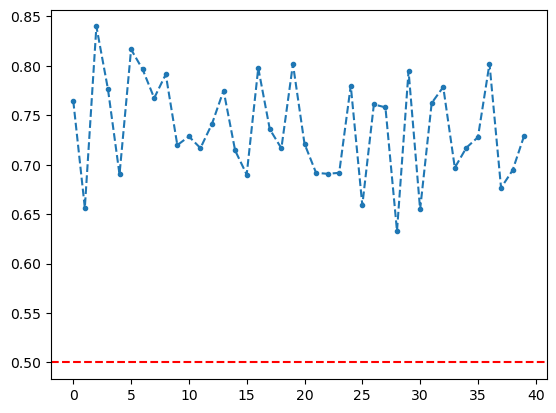

In [17]:
log_gps_z_meaned = payload["log_gps"][payload["index"]["pids_val"]].mean(dim = 2)
log_gps_samples_z_meaned = payload["log_gps_samples_z_meaned"][:,payload["index"]["pids_val"],:]
ppc = (log_gps_samples_z_meaned<log_gps_z_meaned).to(torch.float32).mean(dim=1).mean(dim = 0)
plt.plot(ppc, '.--')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

## Build df_phat

In [18]:
P, T, S = propensity_score.shape
arr = propensity_score.detach().cpu().numpy().reshape(P*T, S)

# id columns
patient_id = np.repeat(np.arange(P), T)
t = np.tile(np.arange(1,T+1), P)

# build dataframe
batch_cols = [f"phat_batch_{i+1}" for i in range(S)]
propensity_df = pd.DataFrame(arr, columns=batch_cols)
propensity_df.insert(0, "t", t)
propensity_df.insert(0, "patient_id", patient_id)

df_phat = df.merge(propensity_df,on=["patient_id", "t"], how="inner")

df_phat["phat_mean"] = df_phat[batch_cols].mean(axis=1)
df_phat["phat_std"] = df_phat[batch_cols].std(axis=1)

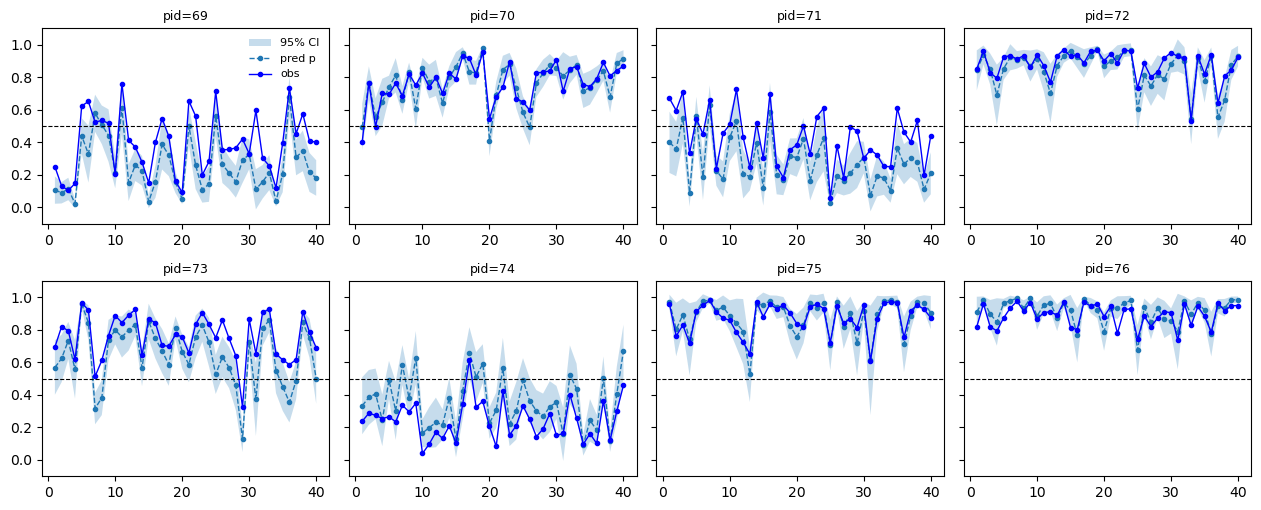

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_patient_grid(pids, df, ncols=4):
    """
    pids: list of patient_ids to show
    df: DataFrame with columns ['patient_id','t','D'] (or at least patient_id & D in order)
    ncols: number of columns in the grid
    """
    n = len(pids)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, pid in zip(axes, pids):
        # get predicted traj
        t = df.loc[df.patient_id == pid, "t"].to_numpy()
        pred = df.loc[df.patient_id == pid, "phat_mean"].to_numpy()

        # get observed traj (assumes rows are in time order)
        obs = df.loc[df.patient_id == pid, "p_true"].to_numpy()



        # confidence band
        lo = df.loc[df.patient_id == pid, "phat_mean"] - 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        hi = df.loc[df.patient_id == pid, "phat_mean"] + 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        ax.fill_between(t, lo, hi, alpha=0.25, linewidth=0, label="95% CI")

        ax.plot(t,pred, "--.", lw=1, label="pred p")
        ax.plot(t,obs, ".-", c="blue", lw=1, label="obs")
        #ax.plot((pred >= 0.5).astype(int), ".-", c="orange", lw=1, label="pred 0/1")
        ax.axhline(0.5, color="k", ls="--", lw=0.8)
        ax.set_ylim(-0.1, 1.1)
        ax.set_title(f"pid={pid}", fontsize=9)

    # hide any unused panels
    for ax in axes[n:]:
        ax.axis("off")

    # one legend
    handles, labels = axes[0].get_legend_handles_labels()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    axes.flat[0].legend(handles, labels, loc="upper right", frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


pids_to_show = sorted(payload["index"]["pids_train"])  # pick any
plot_patient_grid(pids_to_show[50:58], df_phat, ncols=4)

# MSM

## Fix Effect Method 

Exclude the only treated/not treated 

In [20]:
import statsmodels.api as sm

# Identify patients with only treated or only untreated observations
df_temp  = df.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])
exclude_pids = []
if df_temp[df_temp["mean"]==1].shape[0] > 0 or df_temp[df_temp["mean"]==0].shape[0] > 0:
    only_treated_pids = df_temp[df_temp["mean"]==1].index.tolist()
    only_untreated_pids = df_temp[df_temp["mean"]==0].index.tolist()
    exclude_pids = only_treated_pids + only_untreated_pids

# FE vs no-FE propensity estimates on training set using FE_MSM
X_list = [] 
df_msm = df[df.patient_id.isin(train_split) &  ~df.patient_id.isin(exclude_pids)].copy() 

X_list.append(pd.Series(1.0, index=df_msm.index, name="intercept")) 
X_list.append(df_msm[["lag1_D"]]) 
X_list.append(df_msm[df.columns[df.columns.str.startswith("x")].to_list()]) 
## First without fixed effects 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_msm["D"].astype(int).values 

# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_msm["phat_no_fe"] = res.predict(X) 

# Now with fixed effects
fe = pd.get_dummies(df_msm["patient_id"].astype("category"), prefix="u", drop_first=True, dtype=float) 
X_list.append(fe) 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_msm["D"].astype(int).values 
# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_msm["phat_fe"] = res.predict(X)

# Extract fixed effects
fix_effects = [] 
id_fixeffects = {} 
id_fixeffects[sorted(df_msm.patient_id.unique())[0]] = res.params["intercept"] 
# first person in the fe regression 
fix_effects.append(res.params["intercept"]) 
for item in res.params.index[res.params.index.str.startswith("u_")]: 
    fix_effects.append(res.params[item]) 
    id_fixeffects[int(item.split("_")[1])] = res.params[item]




### Diagnostics 

#### Comparison of distribution of mean of the latent variables and fixed effects and true alphas


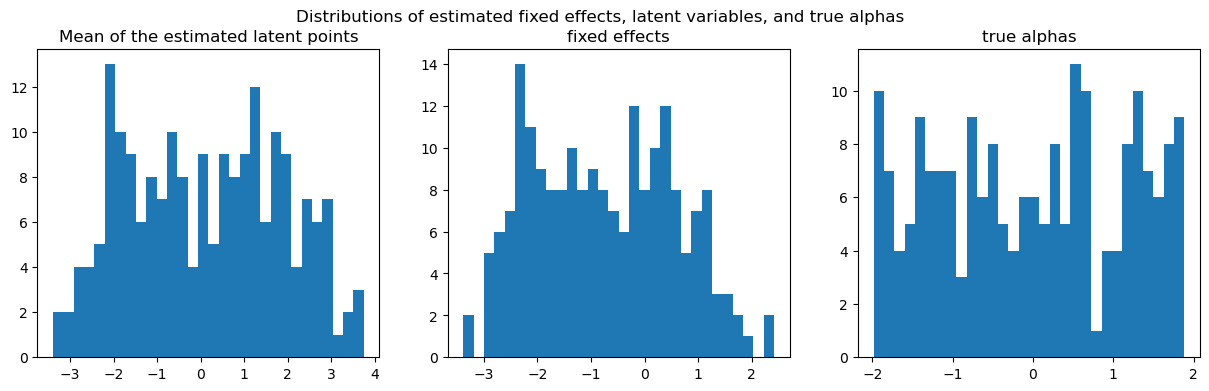

In [32]:

fig,ax = plt.subplots(1,3, figsize=(15,4))
ax[0].hist(param_hist["Z.q_mu"][-1].squeeze(), bins=30)
ax[0].set_title("Mean of the estimated latent points")
ax[2].hist(df[df.patient_id.isin(train_split)].drop_duplicates(subset=["patient_id"])["alpha"], bins=30)
ax[2].set_title("true alphas")
ax[1].hist(fix_effects, bins=30)
ax[1].set_title("fixed effects")
plt.suptitle("Distributions of estimated fixed effects, latent variables, and true alphas", fontsize=12)
plt.show()

#### Correlation Between the estimated fix effect and the true fix effects

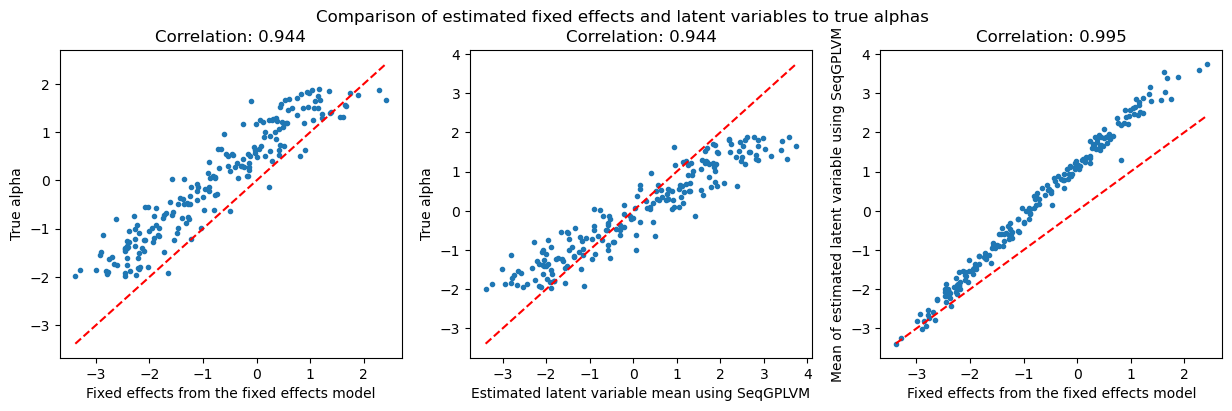

In [33]:
fig,ax = plt.subplots(1,3, figsize=(15,4))
ax[0].plot(fix_effects, df_msm.drop_duplicates(subset=["patient_id"]).sort_values(by="patient_id").alpha.to_numpy(), ".")
ax[0].plot(([min(fix_effects), max(fix_effects)]),
           ([min(fix_effects), max(fix_effects)]),
           "--", color="r")
ax[0].set_xlabel("Fixed effects from the fixed effects model")
ax[0].set_ylabel("True alpha")
corr_fe = np.corrcoef(fix_effects, df_msm.drop_duplicates(subset=["patient_id"]).sort_values(by="patient_id").alpha.to_numpy())[0,1]
ax[0].set_title(f"Correlation: {corr_fe:.3f}")


corr_seqgplvm = np.corrcoef(param_hist["Z.q_mu"][-1].squeeze()[df_train.drop_duplicates(subset=["patient_id"]).train_row.values], df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy())[0,1]
ax[1].plot(param_hist["Z.q_mu"][-1].squeeze()[df_train.drop_duplicates(subset=["patient_id"]).train_row.values], df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy(), ".")
ax[1].plot(([min(param_hist["Z.q_mu"][-1].squeeze()), max(param_hist["Z.q_mu"][-1].squeeze())]),
           ([min(param_hist["Z.q_mu"][-1].squeeze()), max(param_hist["Z.q_mu"][-1].squeeze())]),
           "--", color="r")
ax[1].set_xlabel("Estimated latent variable mean using SeqGPLVM")
ax[1].set_ylabel("True alpha")
ax[1].set_title(f"Correlation: {corr_seqgplvm:.3f}")

ax[2].plot(fix_effects, param_hist["Z.q_mu"][-1].squeeze()[df_train.drop_duplicates(subset=["patient_id"]).train_row.values], ".")
ax[2].set_xlabel("Fixed effects from the fixed effects model")
ax[2].set_ylabel("Mean of estimated latent variable using SeqGPLVM")
ax[2].plot(([min(fix_effects), max(fix_effects)]),
           ([min(fix_effects), max(fix_effects)]),
           "--", color="r")
corr_fe_seqgplvm = np.corrcoef(fix_effects, param_hist["Z.q_mu"][-1].squeeze()[df_train.drop_duplicates(subset=["patient_id"]).train_row.values])[0,1]
ax[2].set_title(f"Correlation: {corr_fe_seqgplvm:.3f}")

plt.suptitle("Comparison of estimated fixed effects and latent variables to true alphas", fontsize=12)

plt.show()

### Estimated Treatment Probability using FE VS True 

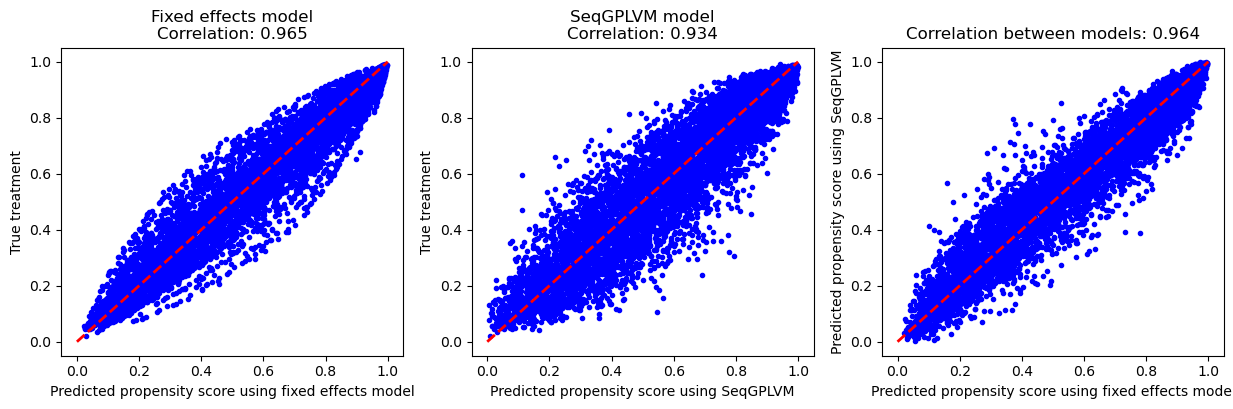

In [34]:
fig,ax = plt.subplots(1,3, figsize=(15,4))

corr_fe = np.corrcoef(df_msm["phat_fe"], df_msm["p_true"])[0,1]
ax[0].set_title(f"Fixed effects model\nCorrelation: {corr_fe:.3f}")
corr_seqgplvm = np.corrcoef(df_phat[df.patient_id.isin(train_split)]["phat_mean"],
                            df_phat[df.patient_id.isin(train_split)]["p_true"])[0,1]
ax[1].set_title(f"SeqGPLVM model\nCorrelation: {corr_seqgplvm:.3f}")
ax[0].plot(df_msm["phat_fe"], df_msm["p_true"],".", c="b", lw=1, label="pred p")
ax[0].plot([0,1],[0,1], "--", c="r", lw=2)
ax[0].set_xlabel("Predicted propensity score using fixed effects model")
ax[0].set_ylabel("True treatment")

ax[1].plot(df_phat[df.patient_id.isin(train_split)]["phat_mean"],
         df_phat[df.patient_id.isin(train_split)]["p_true"],
         ".", c="b", lw=1, label="pred p")
ax[1].plot([0,1],[0,1], "--", c="r", lw=2)
ax[1].set_xlabel("Predicted propensity score using SeqGPLVM")
ax[1].set_ylabel("True treatment")

ax[2].plot(df_msm["phat_fe"], df_phat[df.patient_id.isin(train_split)]["phat_mean"],".", c="b", lw=1, label="pred p")
ax[2].set_xlabel("Predicted propensity score using fixed effects model")
ax[2].set_ylabel("Predicted propensity score using SeqGPLVM")
ax[2].plot([0,1],[0,1], "--", c="r", lw=2)
corr_btw_models = np.corrcoef(df_msm["phat_fe"], df_phat[df.patient_id.isin(train_split)]["phat_mean"])[0,1]
ax[2].set_title(f"Correlation between models: {corr_btw_models:.3f}")

plt.show()

## MSM Comparison

### Using Python

In [ ]:
# First load propensity scores from SeqGPLVM
path = propensity_dir(cwd/Path("./results").expanduser(), "seqgplvm", train_id)
payload = load_ckpt_any(path/f"{os.listdir(path)[-1]}", map_location="cpu")
propensity_score = payload["propensity"]

P, T, S = propensity_score.shape
arr = propensity_score.detach().cpu().numpy().reshape(P*T, S)

# id columns
patient_id = np.repeat(np.arange(P), T)
t = np.tile(np.arange(1,T+1), P)

# build dataframe
batch_cols = [f"phat_batch_{i+1}" for i in range(S)]
propensity_df = pd.DataFrame(arr, columns=batch_cols)
propensity_df.insert(0, "t", t)
propensity_df.insert(0, "patient_id", patient_id)

df_phat = df.merge(propensity_df,on=["patient_id", "t"], how="inner")

df_phat["phat_mean"] = df_phat[batch_cols].mean(axis=1)
df_phat["phat_std"] = df_phat[batch_cols].std(axis=1)

# Identify patients with only treated or only untreated observations
df_temp  = df.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])
exclude_pids = []
if df_temp[df_temp["mean"]==1].shape[0] > 0 or df_temp[df_temp["mean"]==0].shape[0] > 0:
    only_treated_pids = df_temp[df_temp["mean"]==1].index.tolist()
    only_untreated_pids = df_temp[df_temp["mean"]==0].index.tolist()
    exclude_pids = only_treated_pids + only_untreated_pids

# 1) Build df_msm on last k=4 periods, keep only train IDs, drop excluded pids
df_phat["lag_sum"] = df_phat["lag1_D"] + df_phat["lag2_D"] + df_phat["lag3_D"]
df_msm = df_phat[df_phat["patient_id"].isin(train_split)].copy()
df_msm = df_msm[~df_msm["patient_id"].isin(exclude_pids)]
df_msm = df_msm.sort_values(["patient_id", "t"]).reset_index(drop=True)

# FE vs no-FE propensity estimates on training set using FE_MSM
X_list = [] 

X_list.append(pd.Series(1.0, index=df_msm.index, name="intercept")) 
X_list.append(df_msm[["lag1_D"]]) 
X_list.append(df_msm[df.columns[df.columns.str.startswith("x")].to_list()]) 

## First without fixed effects 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_msm["D"].astype(int).values 

# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_msm["phat_no_fe"] = res.predict(X) 

# Now with fixed effects
fe = pd.get_dummies(df_msm["patient_id"].astype("category"), prefix="u", drop_first=True, dtype=float) 
X_list.append(fe) 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_msm["D"].astype(int).values 
# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_msm["phat_fe"] = res.predict(X)

# Now IPTW using SeqGPLVM propensities
## Stabilizing Numerator 
X_list = []

X_list.append(pd.Series(1.0, index=df_msm.index, name="intercept"))
X_list.append(df_msm[["lag1_D"]])

X = pd.concat(X_list, axis=1).astype(float)
y = df_msm["D"].astype(int).values

# GLM Binomial (logit)
model = sm.GLM(y, X, family=sm.families.Binomial())
res = model.fit()

df_msm["stab_num"] = res.predict(X)

T = config["T"]

df_msm = df_msm.loc[
    (df_msm["t"] >= T - 3) & (df_msm["t"] <= T),
    ["patient_id", "t", "D", "lag_sum", "Y", "p_true","stab_num","phat_fe","phat_no_fe"] + batch_cols,
]

# 2) Per-period stabilized weights: w_it = p_num / p_hat or (1-p_num)/(1-p_hat)
D = df_msm["D"].to_numpy().astype(int)
p_num = df_msm["stab_num"].to_numpy()

# batch-wise weights into a DataFrame (same index as df_msm)
weights_df = {}#pd.DataFrame(index=df_msm.index)
for b in batch_cols:
    p_hat = df_msm[b].to_numpy()
    w_b = np.where(D == 1, p_num / p_hat, (1 - p_num) / (1 - p_hat))
    weights_df[b] = w_b
weights_df = pd.DataFrame(weights_df, index=df_msm.index)

# true, FE, no-FE as Series aligned with df_msm
p_true = df_msm["p_true"].to_numpy()
df_msm["w_true"] = np.where(D == 1, p_num / p_true, (1 - p_num) / (1 - p_true))

p_fe = df_msm["phat_fe"].to_numpy()
df_msm["w_fe"] = np.where(D == 1, p_num / p_fe, (1 - p_num) / (1 - p_fe))

p_no_fe = df_msm["phat_no_fe"].to_numpy()
df_msm["w_no_fe"] = np.where(D == 1, p_num / p_no_fe, (1 - p_num) / (1 - p_no_fe))

# 4) Cumulative products over last k periods, by patient
weights_cum = weights_df.groupby(df_msm["patient_id"])[batch_cols].cumprod()
weights_cum.columns = [f"ipw_cum_{c}" for c in batch_cols]

weights_cum["ipw_cum_true"] = (
    df_msm.groupby("patient_id")["w_true"].cumprod()
)
weights_cum["ipw_cum_fe"] = (
    df_msm.groupby("patient_id")["w_fe"].cumprod()
)
weights_cum["ipw_cum_no_fe"] = (
   df_msm.groupby("patient_id")["w_no_fe"].cumprod()
)

# 5) Attach to df_msm via (patient_id, t)
df_msm_ipw = pd.concat([df_msm[["patient_id", "t"]].reset_index(drop=True),
                        weights_cum.reset_index(drop=True)], axis=1)

df_msm = df_msm.merge(df_msm_ipw, on=["patient_id", "t"], how="left")

df_msm_reg = df_msm[df_msm["t"] == T]
y = df_msm_reg["Y"]
X = sm.add_constant(df_msm_reg[["D", "lag_sum"]])

tau_f = []
tau_c = []
for col in [f"ipw_cum_{c}" for c in batch_cols]:
    model = sm.WLS(y, X, weights=df_msm_reg[col])
    res = model.fit()
    tau_f.append(res.params["D"])
    tau_c.append(res.params["lag_sum"])

# true / FE / no-FE

print("Treatment effect estimates:")
print("tau_c_seqgplvm:", np.mean(tau_c), " +/- ", np.std(tau_c))
print("tau_f_seqgplvm:", np.mean(tau_f), " +/- ", np.std(tau_f))
auxiliary = {}
for col, name in [("ipw_cum_true", "true"),
                  ("ipw_cum_fe", "fe"),
                  ("ipw_cum_no_fe", "no_fe")]:
    model = sm.WLS(y, X, weights=df_msm_reg[col])
    res = model.fit()
    auxiliary[name] = {"tau_f":res.params["D"], "tau_c":res.params["lag_sum"]}



Treatment effect estimates:
tau_c_seqgplvm: 0.3656090320615772  +/-  0.10013148691523956
tau_f_seqgplvm: 1.7103878829534391  +/-  0.14889057435588582


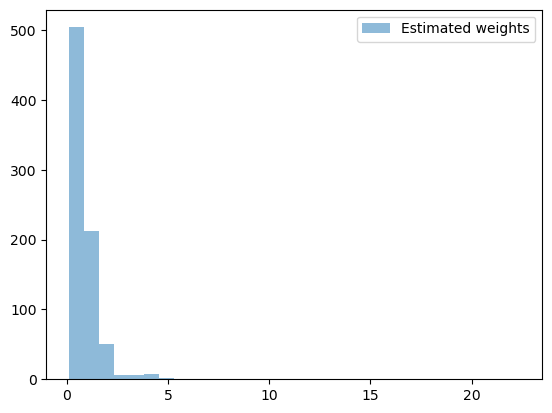

In [40]:
plt.hist(df_msm.filter(regex=r"^ipw_cum_phat_batch").mean(axis=1), bins=30, alpha=0.5, label='Estimated weights')
#plt.hist(df_msm["ipw_cum_true"], bins=30, alpha=0.5, label='True weights')
plt.legend()
plt.show()

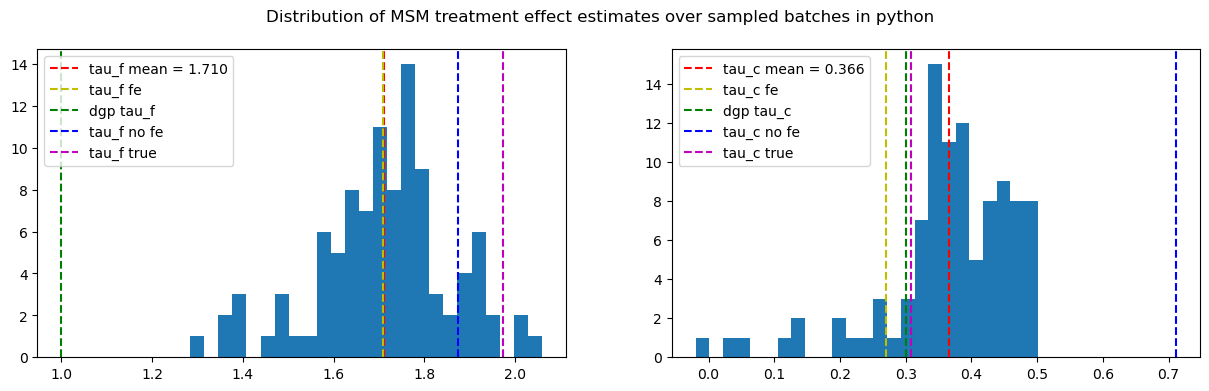

In [44]:
fig,ax = plt.subplots(1,2,figsize = (15,4))
plt.suptitle("Distribution of MSM treatment effect estimates over sampled batches in python")
    
ax[0].hist(np.array(tau_f), bins=25)
ax[0].axvline(x=np.mean(tau_f), color='r', linestyle='--', label=f'tau_f mean = {np.mean(tau_f):.3f}')
ax[0].axvline(x=np.mean(auxiliary["fe"]["tau_f"]), color='y', linestyle='--', label='tau_f fe')
ax[0].axvline(x=mani["params"]["tau_F"], color='g', linestyle='--', label='dgp tau_f')
ax[0].axvline(x=np.mean(auxiliary["no_fe"]["tau_f"]), color='b', linestyle='--', label='tau_f no fe')
ax[0].axvline(x=np.mean(auxiliary["true"]["tau_f"]), color='m', linestyle='--', label='tau_f true')


ax[1].hist(np.array(tau_c), bins=25)
ax[1].axvline(x=np.mean(tau_c), color='r', linestyle='--', label='tau_c mean = {:.3f}'.format(np.mean(tau_c)))
ax[1].axvline(x=np.mean(auxiliary["fe"]["tau_c"]), color='y', linestyle='--', label='tau_c fe')
ax[1].axvline(x=mani["params"]["tau_C"], color='g', linestyle='--', label='dgp tau_c')
ax[1].axvline(x=np.mean(auxiliary["no_fe"]["tau_c"]), color='b', linestyle='--', label='tau_c no fe')
ax[1].axvline(x=np.mean(auxiliary["true"]["tau_c"]), color='m', linestyle='--', label='tau_c true')
ax[0].legend()
ax[1].legend()

plt.show()

### Using R 

In [188]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects import r, default_converter
from rpy2.robjects.conversion import localconverter
from trainers import seqgplvm_msm


P, T, S = propensity_score.shape
arr = propensity_score.detach().cpu().numpy().reshape(P*T, S)

# id columns
patient_id = np.repeat(np.arange(P), T)
t = np.tile(np.arange(1,T+1), P)

# build dataframe
batch_cols = [f"phat_batch_{i+1}" for i in range(S)]
propensity_df = pd.DataFrame(arr, columns=batch_cols)
propensity_df.insert(0, "t", t)
propensity_df.insert(0, "patient_id", patient_id)

df_phat = df.merge(propensity_df,on=["patient_id", "t"], how="inner")

df_phat["phat_mean"] = df_phat[batch_cols].mean(axis=1)
df_phat["phat_std"] = df_phat[batch_cols].std(axis=1)
df_phat["train_id"] = train_id

    

k_last = mani["params"].get("max_lag_d", 4)
a_val = mani["params"].get("a", None)
data_id = mani.get("run_id", None)
with open(as_path(mani.get("split_file"))) as f:
        splits = json.load(f)
train_ids = splits["train_ids"]
val_ids = splits["val_ids"] + splits["test_ids"]
    
x_cols = [col for col in df_phat.columns if col.startswith("x")]
results = []
for i,batch in enumerate(batch_cols):
    print(f"indexing batch {i+1}/{len(batch_cols)} for MSM...")
    with localconverter(default_converter + pandas2ri.converter):
        res_train_py = r["seqgplvm_msm_from_py"](df_phat, train_ids, batch, k_last, a_val, data_id, x_cols)
        res_test_py = r["seqgplvm_msm_from_py"](df_phat, val_ids, batch, k_last, a_val, data_id, x_cols)
            
        
        # Tag which subset this is (train vs val/test)
        res_train_py["subset"] = "train"
        res_test_py["subset"]  = "val"   # or "test" / "val+test", up to you
        res_train_py["train_id"] = train_id
        res_test_py["train_id"]  = train_id
        # Also store whether this run dropped monotone units at the model stage
        res_train_py["drop_monotone_model"] = config["drop_monotone"]
        res_test_py["drop_monotone_model"]  = config["drop_monotone"]

        # Add to list
        results.append(res_train_py)
        results.append(res_test_py)

    if results:
        msm_df = pd.concat(results, ignore_index=True)

        #out_path = msm_dir / f"{train_id}_msm.parquet"
        #msm_df.to_parquet(out_path, index=False)
        #print(f"[{train_id}] Saved MSM results to {out_path} (n={len(msm_df)})")
    else:
        print(f"[{train_id}] WARNING: no MSM results collected.")

indexing batch 1/100 for MSM...
indexing batch 2/100 for MSM...
indexing batch 3/100 for MSM...
indexing batch 4/100 for MSM...
indexing batch 5/100 for MSM...
indexing batch 6/100 for MSM...
indexing batch 7/100 for MSM...
indexing batch 8/100 for MSM...
indexing batch 9/100 for MSM...
indexing batch 10/100 for MSM...
indexing batch 11/100 for MSM...
indexing batch 12/100 for MSM...
indexing batch 13/100 for MSM...
indexing batch 14/100 for MSM...
indexing batch 15/100 for MSM...
indexing batch 16/100 for MSM...
indexing batch 17/100 for MSM...
indexing batch 18/100 for MSM...
indexing batch 19/100 for MSM...
indexing batch 20/100 for MSM...
indexing batch 21/100 for MSM...
indexing batch 22/100 for MSM...
indexing batch 23/100 for MSM...
indexing batch 24/100 for MSM...
indexing batch 25/100 for MSM...
indexing batch 26/100 for MSM...
indexing batch 27/100 for MSM...
indexing batch 28/100 for MSM...
indexing batch 29/100 for MSM...
indexing batch 30/100 for MSM...
indexing batch 31/1

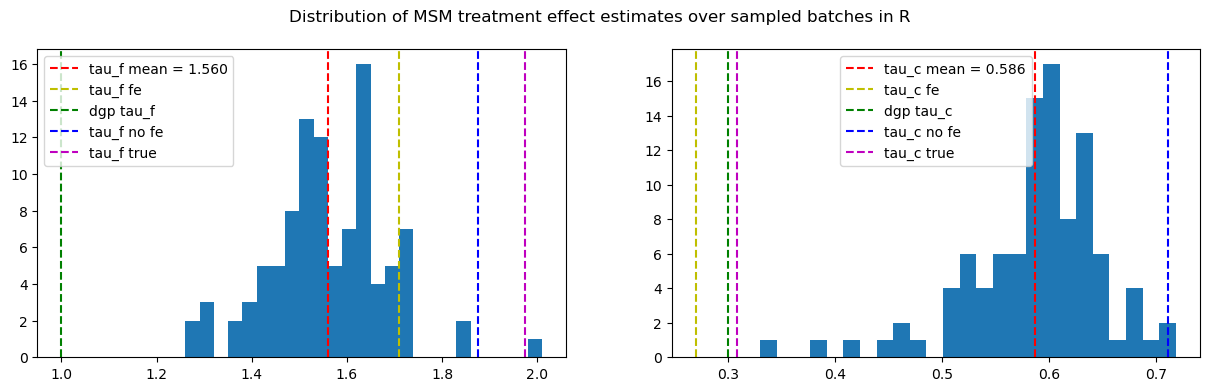

In [218]:
df_msm_results = msm_df_py#pd.read_parquet(cwd/"results"/"msm"/"seqgplvm"/f"{train_id}_msm.parquet") #msm_df
tau_c_seqgplvm =   msm_df_py["tau_c_fe"].values  #df_msm_results.query("subset == 'train'")["tau_c_fe"].values
tau_f_seqgplvm =  msm_df_py["tau_f_fe"].values  #df_msm_results.query("subset == 'train'")["tau_f_fe"].values

fig,ax = plt.subplots(1,2,figsize = (15,4))
plt.suptitle("Distribution of MSM treatment effect estimates over sampled batches in R")
ax[0].hist(np.array(tau_f_seqgplvm), bins=25)
ax[0].axvline(x=np.mean(tau_f_seqgplvm), color='r', linestyle='--', label=f'tau_f mean = {np.mean(tau_f_seqgplvm):.3f}')
ax[0].axvline(x=np.mean(auxiliary["fe"]["tau_f"]), color='y', linestyle='--', label='tau_f fe')
ax[0].axvline(x=mani["params"]["tau_F"], color='g', linestyle='--', label='dgp tau_f')
ax[0].axvline(x=np.mean(auxiliary["no_fe"]["tau_f"]), color='b', linestyle='--', label='tau_f no fe')
ax[0].axvline(x=np.mean(auxiliary["true"]["tau_f"]), color='m', linestyle='--', label='tau_f true')


ax[1].hist(np.array(tau_c_seqgplvm), bins=25)
ax[1].axvline(x=np.mean(tau_c_seqgplvm), color='r', linestyle='--', label=f'tau_c mean = {np.mean(tau_c_seqgplvm):.3f}')
ax[1].axvline(x=np.mean(auxiliary["fe"]["tau_c"]), color='y', linestyle='--', label='tau_c fe')
ax[1].axvline(x=mani["params"]["tau_C"], color='g', linestyle='--', label='dgp tau_c')
ax[1].axvline(x=np.mean(auxiliary["no_fe"]["tau_c"]), color='b', linestyle='--', label='tau_c no fe')
ax[1].axvline(x=np.mean(auxiliary["true"]["tau_c"]), color='m', linestyle='--', label='tau_c true')

ax[0].legend()
ax[1].legend()
plt.show()

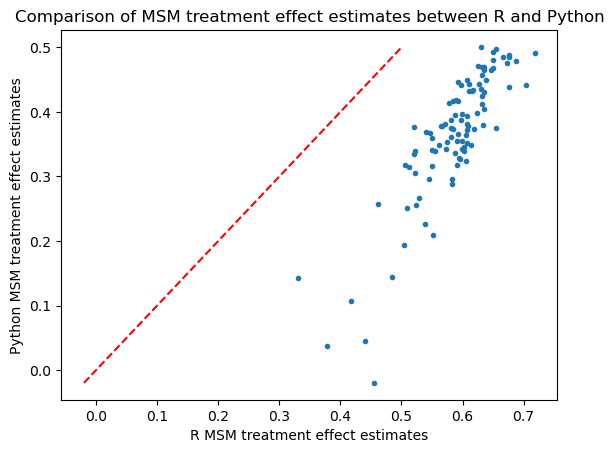

In [220]:
plt.plot(df_msm_results.query("subset == 'train'")["tau_c_fe"].values,tau_c ,".") #df_msm_results.query("subset == 'train'")["tau_c_fe"].values
plt.plot([min(tau_c), max(tau_c)], [min(tau_c), max(tau_c)], "--", color="red")
plt.xlabel("R MSM treatment effect estimates")
plt.ylabel("Python MSM treatment effect estimates")
plt.title("Comparison of MSM treatment effect estimates between R and Python")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


def seqgplvm_msm_from_py_py(
    df: pd.DataFrame,
    train_ids,
    propensity_scores_col: str,
    k_last: int = 4,
    a_val: float | None = None,
    data_id: str | None = None,
    x_cols=None,
    eps: float = 1e-6,
) -> pd.DataFrame:
    """
    Python reimplementation of the R function seqgplvm_msm_from_py().

    Returns a one-row DataFrame with the same fields as the R tibble:
      tau_f_fe, tau_c_fe, tau_f_fe_impute, tau_c_fe_impute,
      and their HC2 standard errors, plus metadata.
    """
    # --- basic checks ---------------------------------------------------------
    if propensity_scores_col not in df.columns:
        raise ValueError(f"{propensity_scores_col!r} is not a column in df")

    req = ["patient_id", "t", "D", "Y", propensity_scores_col]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"df is missing required columns: {missing}")

    # Copy & normalise types
    df = df.copy()
    df["patient_id"] = df["patient_id"].astype(str)
    train_ids = pd.Series(train_ids, dtype=str)

    # --- subset to train_ids & sort (R: filter + arrange(patient_id, t)) ------
    df_fe = df[df["patient_id"].isin(train_ids)].copy()
    df_fe = df_fe.sort_values(["patient_id", "t"]).reset_index(drop=True)

    if df_fe.empty:
        raise ValueError(
            "No rows left after filtering to train_ids in seqgplvm_msm_from_py_py."
        )

    # covariate columns (only used for metadata)
    if x_cols is None:
        x_cols = [c for c in df_fe.columns if c.startswith("x")]
    else:
        x_cols = [str(c) for c in x_cols if c in df_fe.columns]

    # --- classify monotone vs variable-treatment units ------------------------
    meanD = df_fe.groupby("patient_id")["D"].mean()
    var_pids = meanD.index[(meanD != 0) & (meanD != 1)]
    always0_pids = meanD.index[meanD == 0]
    always1_pids = meanD.index[meanD == 1]

    # --- time window for last k periods --------------------------------------
    T_final = int(df_fe["t"].max())
    if k_last < 1:
        raise ValueError("k_last must be >= 1")

    mask_lastk = (df_fe["t"] >= (T_final - (k_last - 1))) & (df_fe["t"] <= T_final)

    # --- build lags if needed (R: mutate lag1_D..lag3_D by group) ------------
    need_lags = not all(c in df_fe.columns for c in ["lag1_D", "lag2_D", "lag3_D"])
    if need_lags:
        df_fe = df_fe.sort_values(["patient_id", "t"])
        df_fe["lag1_D"] = df_fe.groupby("patient_id")["D"].shift(1, fill_value=0)
        df_fe["lag2_D"] = df_fe.groupby("patient_id")["D"].shift(2, fill_value=0)
        df_fe["lag3_D"] = df_fe.groupby("patient_id")["D"].shift(3, fill_value=0)

    df_fe["lag_sum3"] = df_fe["lag1_D"] + df_fe["lag2_D"] + df_fe["lag3_D"]

    # final-time rows (R: df_msm <- filter(df_fe, t == T_final))
    df_msm = df_fe[df_fe["t"] == T_final].copy()

    # metadata: seed (if present)
    seed = df_fe["seed"].iloc[0] if "seed" in df_fe.columns else np.nan

    # --- numerator model: glm(D ~ lag1_D, family=binomial) -------------------
    X_num = sm.add_constant(df_fe[["lag1_D"]].astype(float))
    y_num = df_fe["D"].astype(float)
    num_mod = sm.GLM(y_num, X_num, family=sm.families.Binomial())
    res_num = num_mod.fit()

    p_num = res_num.predict(X_num)
    p_num = np.clip(p_num, eps, 1.0 - eps)

    # denominator: SeqGPLVM propensities from given column (R: df_fe[[col]])
    p_hat = df_fe[propensity_scores_col].astype(float).to_numpy()
    p_hat = np.clip(p_hat, eps, 1.0 - eps)

    D_all = df_fe["D"].astype(int).to_numpy()

    def per_period_w(pn, pd, D_vec):
        return np.where(D_vec == 1, pn / pd, (1.0 - pn) / (1.0 - pd))

    # --- (1) DROP monotone units: FE branch -----------------------------------
    var_mask = df_fe["patient_id"].isin(var_pids)

    # full-length array, NaN for non-var units
    w_fe_it_all = np.full_like(p_num, fill_value=np.nan, dtype=float)
    if var_mask.any():
        w_fe_it_all[var_mask.to_numpy()] = per_period_w(
            p_num[var_mask.to_numpy()],
            p_hat[var_mask.to_numpy()],
            D_all[var_mask.to_numpy()],
        )

    mask_lastk_FE = mask_lastk & var_mask

    if mask_lastk_FE.any():
        tmp_fe = pd.DataFrame(
            {
                "patient_id": df_fe.loc[mask_lastk_FE, "patient_id"].to_numpy(),
                "w": w_fe_it_all[mask_lastk_FE.to_numpy()],
            }
        )
        W_fe_tbl = tmp_fe.groupby("patient_id", sort=False)["w"].prod().reset_index()
    else:
        W_fe_tbl = pd.DataFrame({"patient_id": [], "w": []})

    # --- (2) IMPUTE propensities for monotone units --------------------------
    p_hat_imp = p_hat.copy()

    if len(always0_pids) > 0:
        mask0 = df_fe["patient_id"].isin(always0_pids)
        p_hat_imp[mask0.to_numpy()] = 0.01
    if len(always1_pids) > 0:
        mask1 = df_fe["patient_id"].isin(always1_pids)
        p_hat_imp[mask1.to_numpy()] = 0.99

    p_hat_imp = np.clip(p_hat_imp, eps, 1.0 - eps)

    w_fe_imp_it_all = per_period_w(p_num, p_hat_imp, D_all)

    tmp_imp = pd.DataFrame(
        {
            "patient_id": df_fe.loc[mask_lastk, "patient_id"].to_numpy(),
            "w": w_fe_imp_it_all[mask_lastk.to_numpy()],
        }
    )
    W_fe_imp_tbl = tmp_imp.groupby("patient_id", sort=False)["w"].prod().reset_index()

    # --- align weights with final-time rows ----------------------------------
    df_msm["patient_id"] = df_msm["patient_id"].astype(str)

    # FE (drop monotone)
    df_msm_FE = df_msm[df_msm["patient_id"].isin(var_pids)].copy()
    w_fe_map = W_fe_tbl.set_index("patient_id")["w"]
    df_msm_FE["w_fe"] = w_fe_map.reindex(df_msm_FE["patient_id"]).to_numpy()
    df_msm_FE = df_msm_FE.dropna(subset=["w_fe"])

    # Imputed (all train_ids)
    df_msm_imp = df_msm.copy()
    w_fe_imp_map = W_fe_imp_tbl.set_index("patient_id")["w"]
    df_msm_imp["w_fe_imp"] = w_fe_imp_map.reindex(df_msm_imp["patient_id"]).to_numpy()
    df_msm_imp = df_msm_imp.dropna(subset=["w_fe_imp"])

    # --- weighted least squares with HC2 SEs ---------------------------------
    def fit_wls(data: pd.DataFrame, weight_col: str):
        X = sm.add_constant(data[["D", "lag_sum3"]].astype(float))
        y = data["Y"].astype(float)
        w = data[weight_col].astype(float).to_numpy()
        model = sm.WLS(y, X, weights=w)
        res = model.fit(cov_type="HC2")
        return res

    res_fe = fit_wls(df_msm_FE, "w_fe") if not df_msm_FE.empty else None
    res_fe_imp = fit_wls(df_msm_imp, "w_fe_imp") if not df_msm_imp.empty else None

    # extract coefficients & SEs (like R code)
    tau_f_fe = tau_c_fe = tau_f_fe_se = tau_c_fe_se = np.nan
    if res_fe is not None:
        tau_f_fe = res_fe.params["D"]
        tau_c_fe = res_fe.params["lag_sum3"]
        tau_f_fe_se = res_fe.bse["D"]
        tau_c_fe_se = res_fe.bse["lag_sum3"]

    tau_f_fe_impute = tau_c_fe_impute = tau_f_fe_impute_se = tau_c_fe_impute_se = np.nan
    if res_fe_imp is not None:
        tau_f_fe_impute = res_fe_imp.params["D"]
        tau_c_fe_impute = res_fe_imp.params["lag_sum3"]
        tau_f_fe_impute_se = res_fe_imp.bse["D"]
        tau_c_fe_impute_se = res_fe_imp.bse["lag_sum3"]

    # --- metadata ------------------------------------------------------------
    N = df_fe["patient_id"].nunique()
    T_val = T_final
    rho = int(N / T_val) if T_val > 0 else np.nan
    p_count = len(x_cols)

    out = pd.DataFrame(
        [
            {
                "data_id": data_id,
                "seed": seed,
                "batch": propensity_scores_col,
                "N": N,
                "T": T_val,
                "rho": rho,
                "a": a_val,
                "p": p_count,
                "tau_f_fe": tau_f_fe,
                "tau_c_fe": tau_c_fe,
                "tau_f_fe_impute": tau_f_fe_impute,
                "tau_c_fe_impute": tau_c_fe_impute,
                "tau_f_fe_se": tau_f_fe_se,
                "tau_c_fe_se": tau_c_fe_se,
                "tau_f_fe_impute_se": tau_f_fe_impute_se,
                "tau_c_fe_impute_se": tau_c_fe_impute_se,
            }
        ]
    )
    return out

results = []
for batch in batch_cols:
    res_train_py = seqgplvm_msm_from_py_py(
        df_phat,
        train_ids=train_ids,
        propensity_scores_col=batch,
        k_last=k_last,
        a_val=a_val,
        data_id=data_id,
        x_cols=x_cols,
    )
    res_train_py["subset"] = "train"
    res_train_py["train_id"] = train_id
    results.append(res_train_py)

msm_df_py = pd.concat(results, ignore_index=True)


In [234]:
from rpy2.robjects import r, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

res_dic = {"tau_c_fe_py": [], "tau_f_fe_py": [],
           "tau_c_fe_impute_py": [], "tau_f_fe_impute_py": [],
           "tau_c_fe_R": [], "tau_f_fe_R": [],
           "tau_c_fe_impute_R": [], "tau_f_fe_impute_R": []}
for index,batch in enumerate(batch_cols[:20]):
    print(f"\rindexing batch {index+1}/{len(batch_cols)} for MSM comparison...", end="")
    


    # --- call R function directly ---
    with localconverter(default_converter + pandas2ri.converter):
        res_R = r["seqgplvm_msm_from_py"](df_phat, train_ids, batch, k_last, a_val, data_id, x_cols)



    # --- call Python reimplementation on the same inputs ---
    res_py = seqgplvm_msm_from_py_py(
        df_phat,
        train_ids=train_ids,
        propensity_scores_col=batch,
        k_last=k_last,
        a_val=a_val,
        data_id=data_id,
        x_cols=x_cols,
    )
    # --- collect results ---
    res_dic["tau_c_fe_py"].append(float(res_py["tau_c_fe"].iloc [0]))
    res_dic["tau_f_fe_py"].append(float(res_py["tau_f_fe"].iloc [0]))
    res_dic["tau_c_fe_impute_py"].append(float(res_py["tau_c_fe_impute"].iloc [0]))
    res_dic["tau_f_fe_impute_py"].append(float(res_py["tau_f_fe_impute"].iloc [0]))
    res_dic["tau_c_fe_R"].append(float(res_R["tau_c_fe"].iloc [0]))
    res_dic["tau_f_fe_R"].append(float(res_R["tau_f_fe"].iloc [0]))
    res_dic["tau_c_fe_impute_R"].append(float(res_R["tau_c_fe_impute"].iloc [0]))
    res_dic["tau_f_fe_impute_R"].append(float(res_R["tau_f_fe_impute"].iloc [0]))

# --- convert to DataFrame for analysis ---
res_df = pd.DataFrame(res_dic)





indexing batch 20/100 for MSM comparison...

<Axes: >

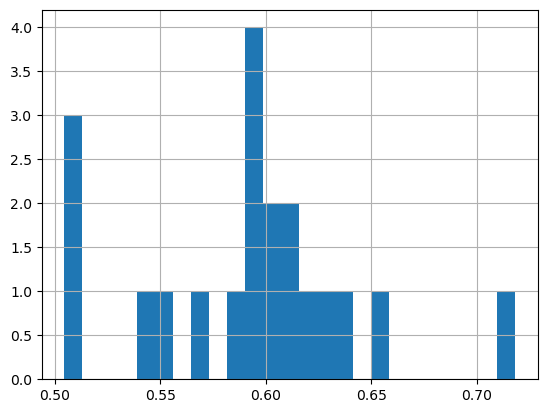

In [235]:
res_df["tau_c_fe_py"].hist(bins=25)

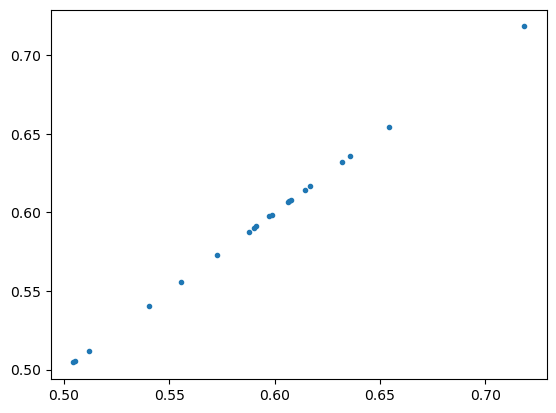

In [236]:
plt.plot(res_df["tau_c_fe_py"], res_df["tau_c_fe_R"], ".")